# EXPLORATORIO
## Definición de Umbral

### Resumen
En este notebook se realiza una exploración de la **definición de un umbral para cubos denoiseados**, utilizando el cubo denoiseado y una versión negativa del original denoiseada, considerando que puede ser una representación correcta de ruido.
Se revisará el procedimiento y su comportamiento en 3 grupos:
1. **Cubo sin denoising:** grupo de control
2. **Cubo denoising por wavelets**
3. **Cubo denoising por U-Net**

### Contexto
A la hora de realizar el cálculo de los momentos de un cubo espectral, normalmente se desea **definir una máscara**, cosa de realizar el procedimiento sólo en las zonas de interés. **Esta máscara define la zona en donde se considera que existe señal real, o donde está presente el objeto de interés**. En los métodos convencionales, la máscara es definida mediante un cálculo basado en el SNR o RMS.

Sin embargo, **en un cubo denoiseado este procedimiento no puede ser realizado de la forma convencional**. La primera razón es que el cubo en estricto rigor ya no presenta ruido, por lo que se debería considerar de que todo lo que aparece es señal. Esto claramente es un acercamiento ingenuo, ya que los procedimientos de denoising nunca logran quitar todo el ruido de una imagen. Por lo tanto, es necesario buscar una metodología alternativa para definir el umbral de la máscara, es decir, desde que punto se puede considerar que la señal es real. El segundo punto a tomar en cuenta es que al realizar un proceso de denoising, el ruido, que en características normales es gaussiano y simétrico alrededor de 0, ya no necesariamente presenta estas características. Por lo tanto, es necesario definir ciertas comprobaciones en pos de definir si los procedimientos de definición de umbral pueden tener en consideración características clásicas de distribución de ruido.

### Metodología


# 0. Importaciones y Configuración

## 0.1. Importaciones

In [1]:
from astropy.io import fits
import astropy.units as u
import astropy.modeling as models
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
import sys

sys.path.append('../../src')

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data'

mkdir -p failed for path /.matplotlib: [Errno 30] Read-only file system: '/.matplotlib'
Matplotlib created a temporary cache directory at /var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/matplotlib-t2cuz0rs because there was an issue with the default path (/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## 0.2. Configuración de Matplotlib

In [2]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 12,
    "figure.figsize": (3.5, 2.625), # 4:3 ratio for single-column
    "savefig.dpi": 600
})


## 0.3. Definición de funciones

### 0.3.1. Broken Power Law

In [3]:
def broken_power_law(x, A1, B1, B2, x_break):
    """Power law quebrada con continuidad en x_break"""
    y = np.where(
        x < x_break,
        A1 * (x / x_break)**B1,
        A1 * (x / x_break)**B2
    )
    return y

# 1. Cubo no denoiseado

## 1.1. Nombre del cubo y directorio

In [8]:
DIR_NAME = 'real_cubes/pointingb'
CUBE_NAME = 'PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube'

## 1.2. Apertura y creación de la versión negativa

In [9]:
# Abrimos el cubo original
hdu = fits.open(os.path.join(DATA_DIR, DIR_NAME, f'{CUBE_NAME}.fits'))

# Obtenemos la data y generamos la versión negativa
data_pos = hdu[0].data
data_neg = hdu[0].data * (-1)

# Obtenemos los valores de flujo
flux_pos = data_pos[
    (np.isfinite(data_pos)) & # Se eliminan los NaN
    (data_pos != 0) # Se eliminan los 0
    ].flatten()

flux_neg = data_neg[
    (np.isfinite(data_neg)) & # Se eliminan los NaN
    (data_neg != 0) # Se eliminan los 0
    ].flatten()


Graficamos un histograma de las dos distribuciones de flujo.

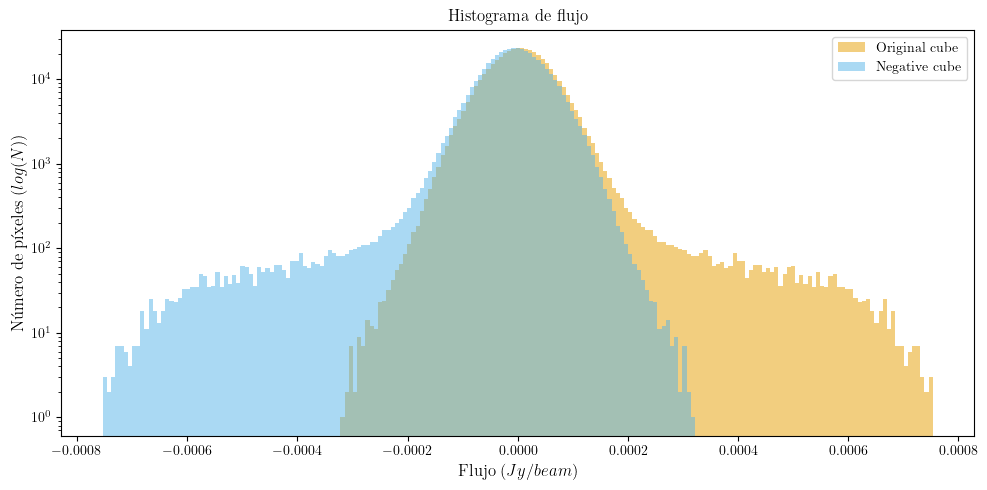

In [11]:
plt.figure(figsize=(10, 5))

# Histograma de flujo positivo.
counts_pos, bin_edges_pos, _  = plt.hist(
    flux_pos,
    bins=np.linspace(flux_neg.min(), flux_pos.max(), 200),
    label='Original cube',
    alpha=0.5
    )

# Histograma de flujo negativo
counts_neg, bin_edges_neg, _  = plt.hist(
    flux_neg,
    bins=np.linspace(flux_neg.min(), flux_pos.max(), 200),
    label='Negative cube',
    alpha=0.5
    )

plt.yscale('log')

plt.xlabel('Flujo ($Jy/beam$)')
plt.ylabel('Número de píxeles ($log(N)$)')
plt.title('Histograma de flujo')

plt.legend()
plt.tight_layout()
plt.show()

Lo interesante de este gráfico es observar cómo el comportamiento del ruido tiende a ser una gaussiana simétrica por ambos lados, tanto en negativo como en positivo.

## 1.3. Razón entre counts de los bins

Sólo se estudia la parte mayor a 0.

In [12]:
flux_neg_pos = flux_neg[flux_neg > 0]
flux_pos_pos = flux_pos[flux_pos > 0]

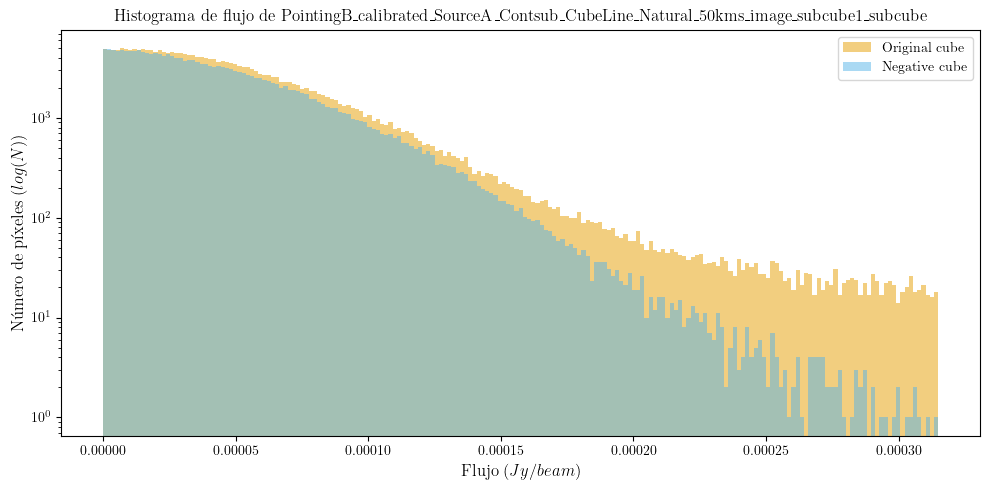

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

counts_pos, bin_edges_pos, _ = plt.hist(
    flux_pos_pos,
    alpha=0.5,
    label='Original cube',
    bins=np.linspace(0, flux_neg_pos.max(), 200),
    )

counts_neg, bin_edges_neg, _ = plt.hist(
    flux_neg_pos,
    alpha=0.5,
    label='Negative cube',
    bins=np.linspace(0, flux_neg_pos.max(), 200),
    )

plt.yscale('log')

plt.xlabel('Flujo ($Jy/beam$)')
plt.ylabel('Número de píxeles ($log(N)$)')
plt.title(f'Histograma de flujo de {CUBE_NAME}')

plt.legend()
plt.tight_layout()

In [14]:
bin_center_pos = (bin_edges_pos[:-1] + bin_edges_pos[1:]) / 2
bin_center_neg = (bin_edges_neg[:-1] + bin_edges_neg[1:]) / 2

counts_pos_mod = counts_pos.copy()
counts_pos_mod[counts_pos_mod == 0] = 1
counts_neg_mod = counts_neg.copy()
counts_neg_mod[counts_neg_mod == 0] = 1

Text(0.5, 0, 'F [Jy/beam]')

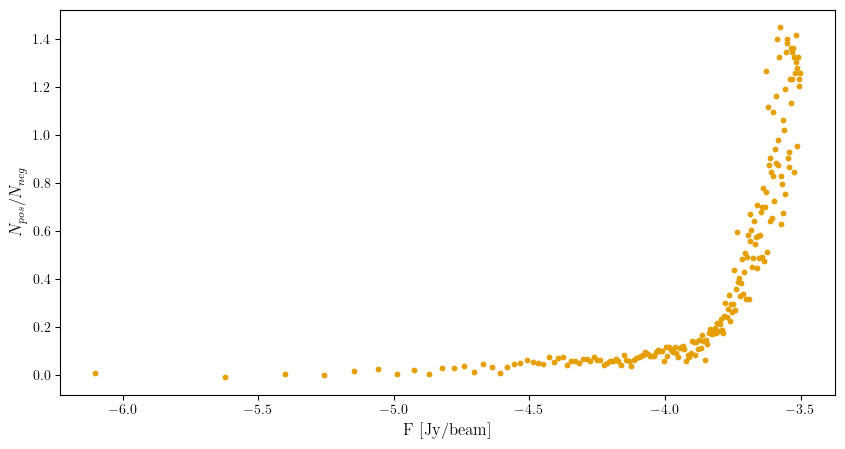

In [15]:
div_counts = counts_pos_mod / counts_neg_mod

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(np.log10(bin_center_neg), np.log10(div_counts), s=10)
ax.set_ylabel('$N_{pos}/N_{neg}$')
ax.set_xlabel('F [Jy/beam]')


In [16]:
x_fit = np.linspace(bin_center_neg.min(), bin_center_neg.max(), 200) 

# ! Estimación inicial [A1, B1, B2, x_break]
# A1: Multiplicador
# B1: Potencia zona plana
# B2: Potencia zona subida
# x_break: Punto de cambio de régimen
p0 = [1, 0.0, 2.0, 5e-4]

popt, pcov = curve_fit(
    broken_power_law,
    bin_center_neg,
    div_counts,
    p0=p0,
    sigma=div_counts,
    maxfev=50000
)

print(f"x_break = {popt[3]:.2e}")
print(f"B1 (zona plana) = {popt[1]:.3f}")

x_break = 1.58e-04
B1 (zona plana) = 0.088


/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_36495/595506434.py:5: RuntimeWarning: invalid value encountered in power
  A1 * (x / x_break)**B1,


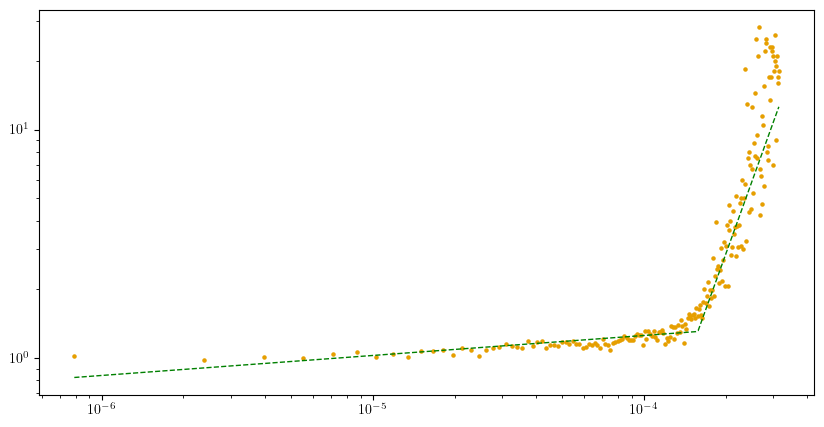

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(bin_center_neg, div_counts, s=5)

ax.plot(x_fit, broken_power_law(x_fit, *popt), 'g--', linewidth=1,
         label=f'Power Law: $A={popt[0]:.2e},\\ B={popt[1]:.2e},\\ C={popt[2]:.2e}$')
plt.yscale('log')
plt.xscale('log')

# 2. Cubo denoiseado por Wavelets

In [13]:
# Apertura de los cubos
hdu_pos = fits.open(os.path.join(DATA_DIR, DIR_NAME, f'{CUBE_NAME}_wavelets_5_soft.fits'))
hdu_neg = fits.open(os.path.join(DATA_DIR, DIR_NAME, f'{CUBE_NAME}_wavelets_5_soft_negative.fits'))

#Obtención data positiva
data_pos = hdu_pos[0].data
flux_pos = data_pos[
    (np.isfinite(data_pos)) & # Se eliminan los NaN
    (data_pos != 0) # Se eliminan los 0
    ].flatten()

#Obtención data negativa
data_neg = hdu_neg[0].data
flux_neg = data_neg[
    (np.isfinite(data_neg)) & # Se eliminan los NaN
    (data_neg != 0) # Se eliminan los 0
    ].flatten()

Generamos un histograma para observar la distribución de flujo de ambos cubos. El binneo sólo se realiza dentro del rango en donde el cubo negativo tiene valores de flujo, al ser nuestra región de interés.

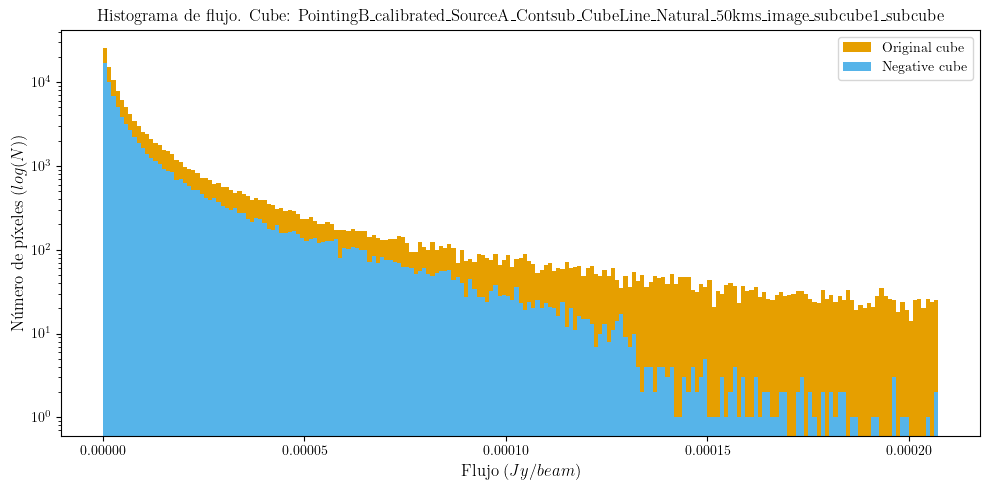

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    flux_pos,
    bins=np.linspace(0, np.max(flux_neg), 200),
    linewidth=0.3,
    label='Original cube'
    )

plt.hist(
    flux_neg,
    bins=np.linspace(0, np.max(flux_neg), 200),
    linewidth=0.3,
    label='Negative cube'
    )

plt.yscale('log')

plt.xlabel('Flujo ($Jy/beam$)')
plt.ylabel('Número de píxeles ($log(N)$)')
plt.title(f'Histograma de flujo. Cube: {CUBE_NAME}')

plt.legend()
plt.tight_layout()

## 2.1. Escalamiento de la distribución de flujo negativa.

En el caso de un cubo denoiseado, se ha observado que, aunque las distribuciones de flujo de ambos cubos siguen siendo similares en forma, el cubo negativo tiende a tener muchos menos valores que el cubo positivo. Por lo tanto, para realizar una comparación apropiada entre las distribuciones, se debe realizar un procedimiento de escalado de la distribución negativa.

### 2.1.1. Escalado por región de bajo flujo dominada por ruido

La idea es elegir un rango de flujo bajo donde *a priori* se considera que ambas distribuciones son de ruido puro. El factor de escala se calcularía de la siguiente manera:

$$
s = \frac{\sum_{i\in ventana}N_i^+}{\sum_{i\in ventana}N_i^-}
$$

Posteriormente, se aplica $s$ a todo el histograma negativo y se comparan las formas. Esto es esencialmente lo que se hace en pipelines de detección de fuentes para fijar el nivel de fondo.

In [15]:
flux_pos_s = flux_pos[flux_pos < 0.00004]
flux_neg_s = flux_neg[flux_neg < 0.00004]

s = np.sum(flux_pos_s) / np.sum(flux_neg_s)
print(s)

1.6380874


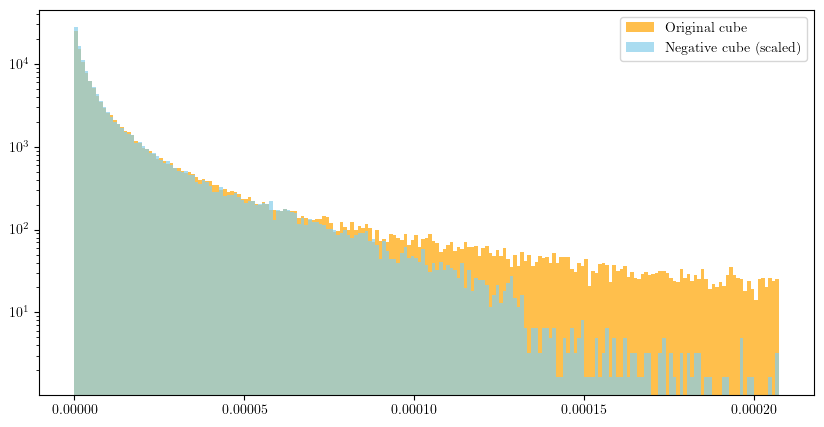

In [16]:
# bins comunes para ambos cubos — esto es importante
bins = np.linspace(0, np.max(flux_neg), 200)

# conteos crudos
counts_pos, edges = np.histogram(flux_pos, bins=bins)
counts_neg, _     = np.histogram(flux_neg, bins=bins)

counts_neg_scaled = counts_neg * s

# dibujar con plt.bar / plt.stairs en vez de plt.hist
centers = 0.5 * (edges[:-1] + edges[1:])
width = np.diff(edges)

plt.figure(figsize=(10, 5))
plt.bar(centers, counts_pos, width=width, align='center',
        color='orange', alpha=0.7, label='Original cube')
plt.bar(centers, counts_neg_scaled, width=width, align='center',
        color='skyblue', alpha=0.7, label='Negative cube (scaled)')
plt.yscale('log')
plt.legend()

Text(0.5, 0, 'F [Jy/beam]')

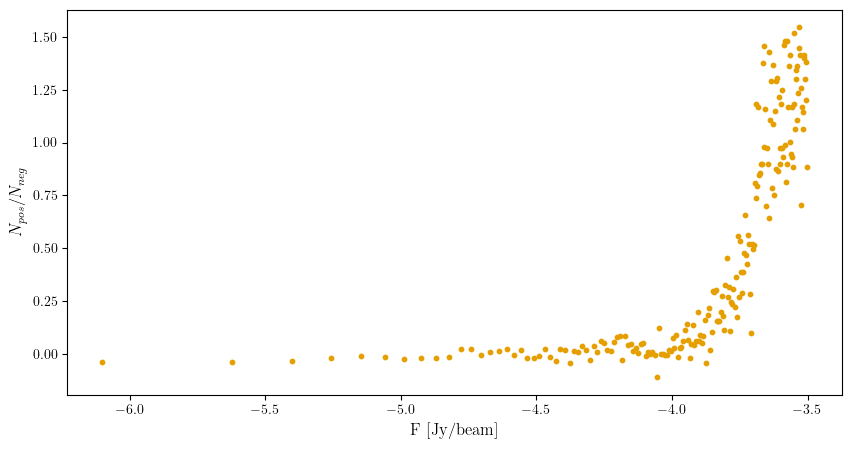

In [17]:
bin_center_pos = (bin_edges_pos[:-1] + bin_edges_pos[1:]) / 2
bin_center_neg = (bin_edges_neg[:-1] + bin_edges_neg[1:]) / 2

counts_pos_mod = counts_pos.copy()
counts_pos_mod[counts_pos_mod == 0] = 1
counts_neg_mod = counts_neg_scaled.copy()
counts_neg_mod[counts_neg_mod == 0] = 1

div_counts = counts_pos_mod / counts_neg_mod

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(np.log10(bin_center_neg), np.log10(div_counts), s=10)
ax.set_ylabel('$N_{pos}/N_{neg}$')
ax.set_xlabel('F [Jy/beam]')

In [18]:
x_fit = np.linspace(bin_center_neg.min(), bin_center_neg.max(), 200) 

# ! Estimación inicial [A1, B1, B2, x_break]
# A1: Multiplicador
# B1: Potencia zona plana
# B2: Potencia zona subida
# x_break: Punto de cambio de régimen
p0 = [1, 0.0, 2.0, 1e-4]

popt, pcov = curve_fit(
    broken_power_law,
    bin_center_neg,
    div_counts,
    p0=p0,
    sigma=div_counts,
    maxfev=50000
)

print(f"x_break = {popt[3]:.2e}")
print(f"B1 (zona plana) = {popt[1]:.3f}")

x_break = 1.40e-04
B1 (zona plana) = 0.053


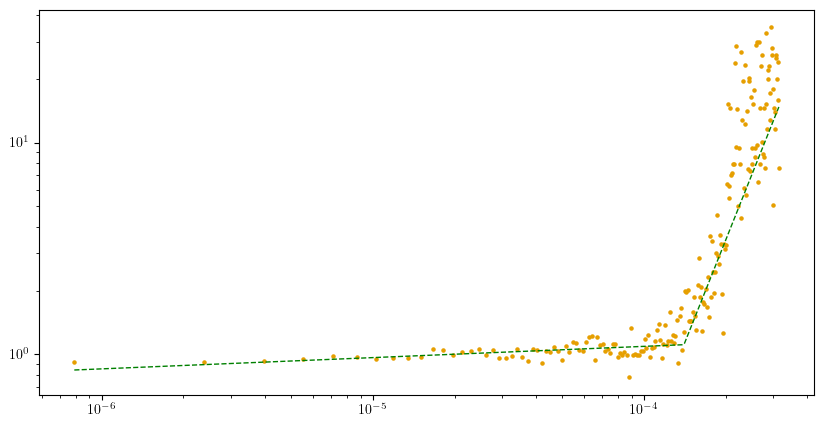

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(bin_center_neg, div_counts, s=5)

ax.plot(x_fit, broken_power_law(x_fit, *popt), 'g--', linewidth=1,
         label=f'Power Law: $A={popt[0]:.2e},\\ B={popt[1]:.2e},\\ C={popt[2]:.2e}$')
plt.yscale('log')
plt.xscale('log')

Bien, el resultado es bastante satisfactorio. **Problemática**: por ahora estamos dependiendo de una ventana arbitraria. Veamos si podemos definir una metodología robusta para la definición del cálculo de la escala.

### 2.1.2. Ajuste por mínimos cuadrados
En vez de fijar una ventana dura, se realiza un ajuste de $s$ minimizando la discrepancia entre $N^+$ y $s\cdot N^-$ sobre el rango de bajo flujo, idealmente ponderando cada bin por su **incertidumbre poissoniana** ($\sigma_i=\sqrt{N_i}$). Esta metodología entrega un $s$ con una barra de error y es menos sensible a la frontera exacta de la ventana. Se podría decir que es la versión "estadísticamente correcta" del método anterior.

#### Planteamiento estadístico
Para un solo parámetro $s$ multiplicativo, existe una solución analítica - por lo que no se necesita un optimizador. Si se modela $N_i^+ \simeq s\cdot N_i^-$ y se realiza una minimización:

$$
\Chi^2(s) = \sum_{i \in ventana}\frac{(N_i^+ - sN_i^-)^2}{\sigma_i^2}
$$

derivando respecto a $s$ e igualando a cero, se logra obtener el estimador de mínimos cuadrados ponderado en forma cerrada:

$$
\hat{s} = \frac{\sum_i w_i N_i^- N_i^+}{\sum_i w_i (N_i^-)^2}
$$
$$
\sigma_{\hat{s}}^2=\frac{1}{\sum_i w_i (N_i^-)^2}
$$

con $w_i=1/\sigma_i^2$. La única sutileza a tomar en cuenta es qué se pone en $\sigma_i^2$. Cómo se están comparando dos conteos, la varianza de la diferencia $N_i^+-sN_i^-$ es la suma de ambas varianzas poissonianas: $\sigma_i^2=N_i^++s^2N_i^-$. Esto hace que $\hat{s}$ aparezca en su propio peso, así que en la práctica se resuelve iterando un par de veces (la convergencia es rápida).

#### Cómo leer resultados
El $\Chi^2_{red}$ es el control de calidad. Si sale cercano a 1, el modelo $N^+=sN^-$ + ruido poissoniano describe bien la ventana, es decir, en ese rango ambas distribuciones de verdad tienen la misma forma salvo el factor $s$ - que es justamente la hipótesis que se necesita validar antes de confiar en el escalado. Si sale >>1, la ventana incluye flujos donde las formas ya divergen (probablemente se ingresó demasiado arriba, hacia la forma de transición del thresholding) o donde el denoising deformó cada cubo de modo distinto. Si sale <<1, probablemente las barras de error estén sobreestimadas - y aquí entra la correlación del beam, porque los bins no son tan independientes como asume el conteo poissoniano crudo.

El **test de robustez imprescindible**: correr `estimar_s`con varios límites superiores de ventana y verificar que $\hat{s}$ es estale dentro de su barra de error. Si $\hat{s}$ deriva sistemáticamente al mover el límite, la "región de ruido puro" no es tan limpia como parece y el umbral final heradará esa ambigüedad - conviene reportarla explícitamente.

In [46]:
def estimar_s(counts_pos, counts_neg, edges, ventana):
    """
    Ajuste de mínimos cuadrados ponderado del factor de escala s
    tal que counts_pos ~ s * counts_neg en la ventana de bajo flujo.

    ventana: (flujo_min, flujo_max) - rango dominado por ruido residual
    """
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = (centers >= ventana[0]) & (centers <= ventana[1])

    Np = counts_pos[mask].astype(float)
    Nn = counts_neg[mask].astype(float)

    # descartar bins vacíos en el negativo (no aportan y rompen los pesos)
    ok = Nn > 0
    Np, Nn = Np[ok], Nn[ok]

    # iteración: s aparece en su propia varianza
    s = np.sum(Nn * Np) / np.sum(Nn**2)   # inicialización sin pesos
    for _ in range(10):
        var = Np + s**2 * Nn              # varianza poissoniana de la diferencia
        var = np.where(var > 0, var, 1.0) # guarda contra division por cero
        w = 1.0 / var
        s_new = np.sum(w * Nn * Np) / np.sum(w * Nn**2)
        if abs(s_new - s) < 1e-10:
            s = s_new
            break
        s = s_new

    sigma_s = np.sqrt(1.0 / np.sum(w * Nn**2))

    # chi2 reducido como diagnóstico de bondad de ajuste
    resid = Np - s * Nn
    chi2 = np.sum(resid**2 / var)
    dof = len(Np) - 1
    chi2_red = chi2 / dof if dof > 0 else np.nan

    return s, sigma_s, chi2_red


In [47]:
s, sigma_s, chi2_red = estimar_s(counts_pos, counts_neg, edges,
                                 ventana=(0.0, 0.00004))
print(f"s = {s:.4f} ± {sigma_s:.4f}   (chi2_red = {chi2_red:.2f})")

s = 1.5653 ± 0.0076   (chi2_red = 2.79)


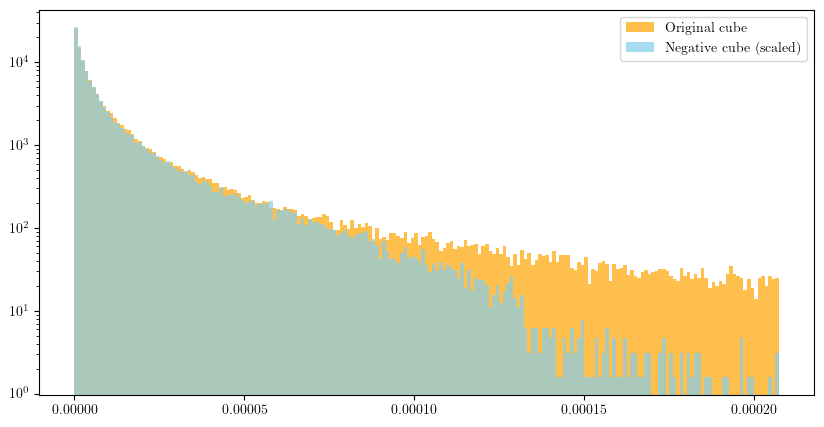

In [48]:
# bins comunes para ambos cubos — esto es importante
bins = np.linspace(0, np.max(flux_neg), 200)

# conteos crudos
counts_pos, edges = np.histogram(flux_pos, bins=bins)
counts_neg, _     = np.histogram(flux_neg, bins=bins)

counts_neg_scaled = counts_neg * s

# dibujar con plt.bar / plt.stairs en vez de plt.hist
centers = 0.5 * (edges[:-1] + edges[1:])
width = np.diff(edges)

plt.figure(figsize=(10, 5))
plt.bar(centers, counts_pos, width=width, align='center',
        color='orange', alpha=0.7, label='Original cube')
plt.bar(centers, counts_neg_scaled, width=width, align='center',
        color='skyblue', alpha=0.7, label='Negative cube (scaled)')
plt.yscale('log')
plt.legend()

Text(0.5, 0, 'F [Jy/beam]')

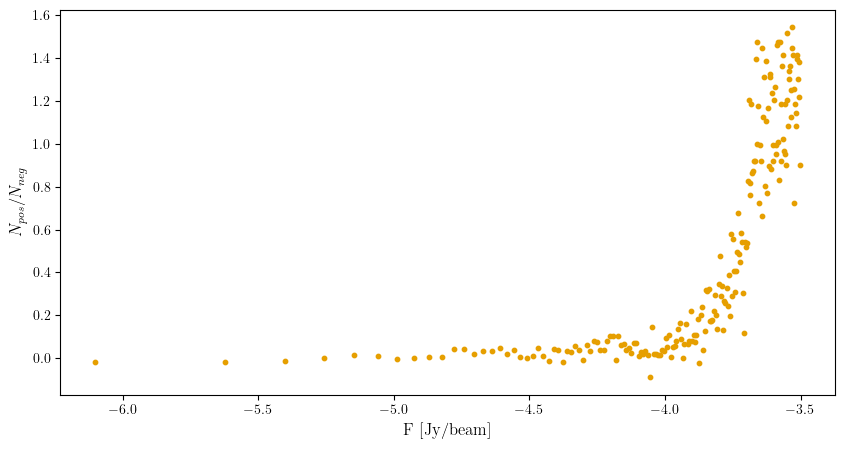

In [49]:
bin_center_pos = (bin_edges_pos[:-1] + bin_edges_pos[1:]) / 2
bin_center_neg = (bin_edges_neg[:-1] + bin_edges_neg[1:]) / 2

counts_pos_mod = counts_pos.copy()
counts_pos_mod[counts_pos_mod == 0] = 1
counts_neg_mod = counts_neg_scaled.copy()
counts_neg_mod[counts_neg_mod == 0] = 1

div_counts = counts_pos_mod / counts_neg_mod

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(np.log10(bin_center_neg), np.log10(div_counts), s=10)
ax.set_ylabel('$N_{pos}/N_{neg}$')
ax.set_xlabel('F [Jy/beam]')

In [50]:
x_fit = np.linspace(bin_center_neg.min(), bin_center_neg.max(), 200) 

# ! Estimación inicial [A1, B1, B2, x_break]
# A1: Multiplicador
# B1: Potencia zona plana
# B2: Potencia zona subida
# x_break: Punto de cambio de régimen
p0 = [1, 0.0, 2.0, 1e-4]

popt, pcov = curve_fit(
    broken_power_law,
    bin_center_neg,
    div_counts,
    p0=p0,
    sigma=div_counts,
    maxfev=50000
)

print(f"x_break = {popt[3]:.2e}")
print(f"B1 (zona plana) = {popt[1]:.3f}")

x_break = 1.40e-04
B1 (zona plana) = 0.052


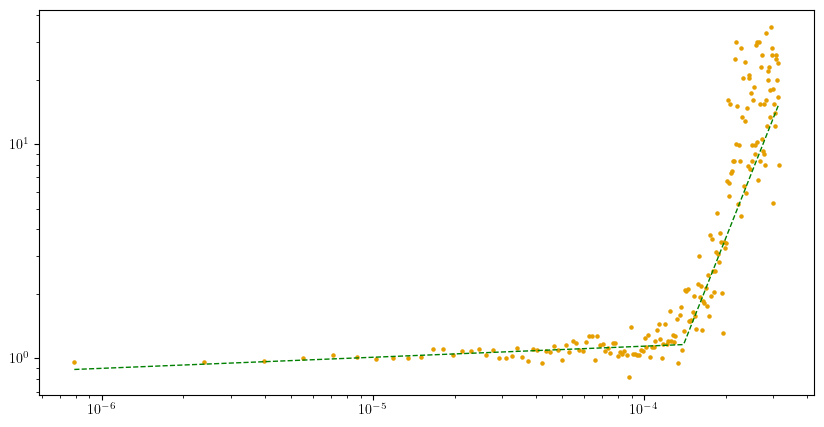

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(bin_center_neg, div_counts, s=5)

ax.plot(x_fit, broken_power_law(x_fit, *popt), 'g--', linewidth=1,
         label=f'Power Law: $A={popt[0]:.2e},\\ B={popt[1]:.2e},\\ C={popt[2]:.2e}$')
plt.yscale('log')
plt.xscale('log')

# 3. Comparación de la distribución de counts según cubes y procedimiento de denoising.

Nos interesa revisar si la propiedad observada en el punto anterior se generaliza en los distintos cubos y utilizando los distintos métodos de denoising.

## 3.1. Mismo cubo, distinto denoising

In [170]:
CUBE_NAME = 'CONDOR06LD_spw27_18kms_r05_subcube1'

hdu_negative = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}_wavelets_5_soft_negative.fits'))
data_negative = hdu_negative[0].data
flux_values_negative = data_negative[np.isfinite(data_negative) & (data_negative != 0)]



hdu_positive = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}_wavelets_5_soft.fits'))
data_positive = hdu_positive[0].data
flux_values_positive = data_positive[np.isfinite(data_positive) & (data_positive != 0)]

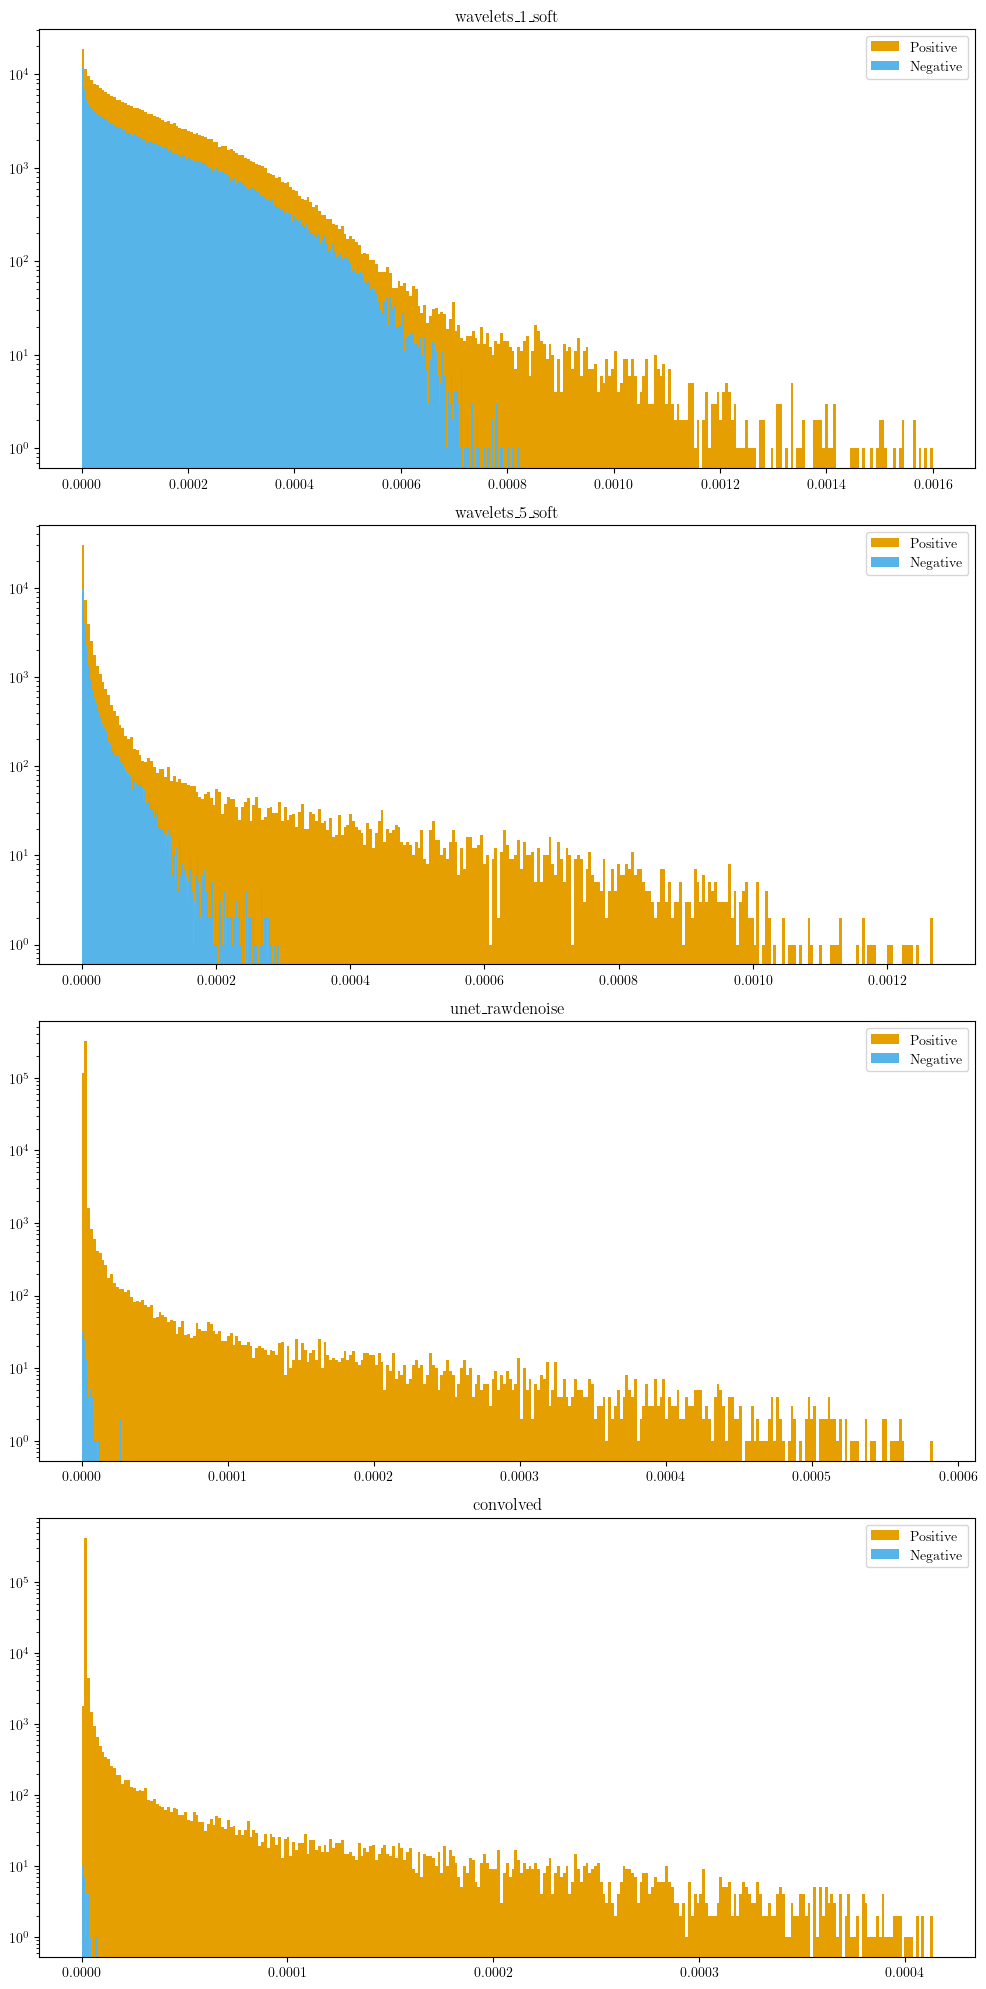

In [ ]:
pares = (
    ('_wavelets_1_soft', '_wavelets_1_soft_negative'),
    ('_wavelets_5_soft', '_wavelets_5_soft_negative'),
    ('_unet_rawdenoise', '_unet_rawdenoise_negative'),
    ('_convolved', '_convolved_negative'),
)


fig, axs = plt.subplots(figsize=(10, 20), ncols=1, nrows=len(pares))

for idx, (sufijo_pos, sufijo_neg) in enumerate(pares):
    hdu_positive = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}{sufijo_pos}.fits'))
    data_positive = hdu_positive[0].data
    flux_values_positive = data_positive[np.isfinite(data_positive) & (data_positive != 0)]

    hdu_negative = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}{sufijo_neg}.fits'))
    data_negative = hdu_negative[0].data
    flux_values_negative = data_negative[np.isfinite(data_negative) & (data_negative != 0)]

    axs[idx].hist(flux_values_positive, bins=np.linspace(0, flux_values_positive.max(), 300), label='Positive')
    axs[idx].hist(flux_values_negative, bins=np.linspace(0, flux_values_negative.max(), 300), label='Negative')
    axs[idx].set_yscale('log')
    axs[idx].set_title(sufijo_pos.strip('_'))
    axs[idx].legend()

plt.tight_layout()
